# Module 3 - Predictive Modeling and Scenario Analysis
Nigeria Macroeconomic Intelligence & Labour Market Analytics Platform

Models: 3.1 Feature Engineering | 3.2 ARIMA/SARIMAX | 3.3 Prophet | 3.4 XGBoost+SHAP | 3.5 Comparison | 3.6 Scenario Analysis

## Setup - Imports and Configuration

In [1]:
import sys
!{sys.executable} -m pip install folium pingouin prophet shap geopandas

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [2]:
import sys
!{sys.executable} -m pip install xgboost shap prophet folium pingouin geopandas

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import os
import logging
warnings.filterwarnings('ignore')
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import shap
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

DATA   = os.getcwd()
OUTPUT = os.path.join(DATA, 'outputs')
os.makedirs(OUTPUT, exist_ok=True)
print(f"Working directory: {DATA}")
print(f"Output folder    : {OUTPUT}")

Working directory: /home/a0878fb7-b331-4998-8538-65574a32993a
Output folder    : /home/a0878fb7-b331-4998-8538-65574a32993a/outputs


In [4]:
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.alpha': 0.3, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False, 'figure.dpi': 120,
})
print("Style configured.")

Style configured.


## Load Datasets

In [5]:
gdp    = pd.read_csv('nigeria_quarterly_gdp.csv')
panel  = pd.read_csv('nigeria_master_quarterly_panel.csv')
states = pd.read_csv('nigeria_state_unemployment_2023.csv')
cpi    = pd.read_csv('nigeria_cpi_monthly.csv')
oil_m  = pd.read_csv('nigeria_oil_production_monthly.csv')
brent  = pd.read_csv('brent_crude_monthly.csv')
print("All datasets loaded.")

All datasets loaded.


---
## Task 3.1 - Feature Engineering and Dataset Preparation

In [6]:
gdp_ts     = gdp['gdp_growth_yoy_pct'].values
n          = len(gdp_ts)
train_size = int(n * 0.8)
print(f"GDP series : {n} quarters")
print(f"Train      : {train_size} ({gdp.iloc[0]['period']} to {gdp.iloc[train_size-1]['period']})")
print(f"Test       : {n-train_size} ({gdp.iloc[train_size]['period']} to {gdp.iloc[-1]['period']})")

GDP series : 36 quarters
Train      : 28 (2015-Q1 to 2021-Q4)
Test       : 8 (2022-Q1 to 2023-Q4)


In [7]:
cpi_m = cpi.merge(brent[['period','brent_price_usd']], on='period', how='left')
cpi_m = cpi_m.merge(oil_m[['period','exchange_rate_ngn_usd']], on='period', how='left')
n_cpi          = len(cpi_m)
train_size_cpi = int(n_cpi * 0.8)
print(f"CPI series : {n_cpi} months | Train: {train_size_cpi} | Test: {n_cpi-train_size_cpi}")

CPI series : 108 months | Train: 86 | Test: 22


In [8]:
exog_oil   = panel['brent_price_avg_usd'].ffill().values
y_train    = gdp_ts[:train_size]
y_test     = gdp_ts[train_size:]
exog_train = exog_oil[:train_size].reshape(-1,1)
exog_test  = exog_oil[train_size:].reshape(-1,1)
print("Train/test splits ready.")
print(f"Lag features available: {[c for c in panel.columns if 'lag' in c or 'rolling' in c]}")

Train/test splits ready.
Lag features available: ['gdp_growth_lag1', 'gdp_growth_lag4', 'inflation_lag1', 'rolling_4q_gdp_mean', 'rolling_4q_gdp_std']


---
## Task 3.2 - ARIMA / SARIMAX: GDP Growth Forecasting

### Stationarity Tests

In [9]:
adf_result  = adfuller(gdp_ts, autolag='AIC')
kpss_result = kpss(gdp_ts, regression='c', nlags='auto')
print(f"ADF Test  : stat={adf_result[0]:.4f}, p={adf_result[1]:.4f} -> {'Stationary' if adf_result[1]<0.05 else 'Non-Stationary'}")
print(f"KPSS Test : stat={kpss_result[0]:.4f}, p={kpss_result[1]:.4f} -> {'Stationary' if kpss_result[1]>0.05 else 'Non-Stationary'}")
d = 1 if adf_result[1] > 0.05 else 0
print(f"Differencing order: d={d}")

ADF Test  : stat=-2.6096, p=0.0910 -> Non-Stationary
KPSS Test : stat=0.1857, p=0.1000 -> Stationary
Differencing order: d=1


/tmp/ipykernel_1148/3537440747.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(gdp_ts, regression='c', nlags='auto')


### ACF and PACF Plots

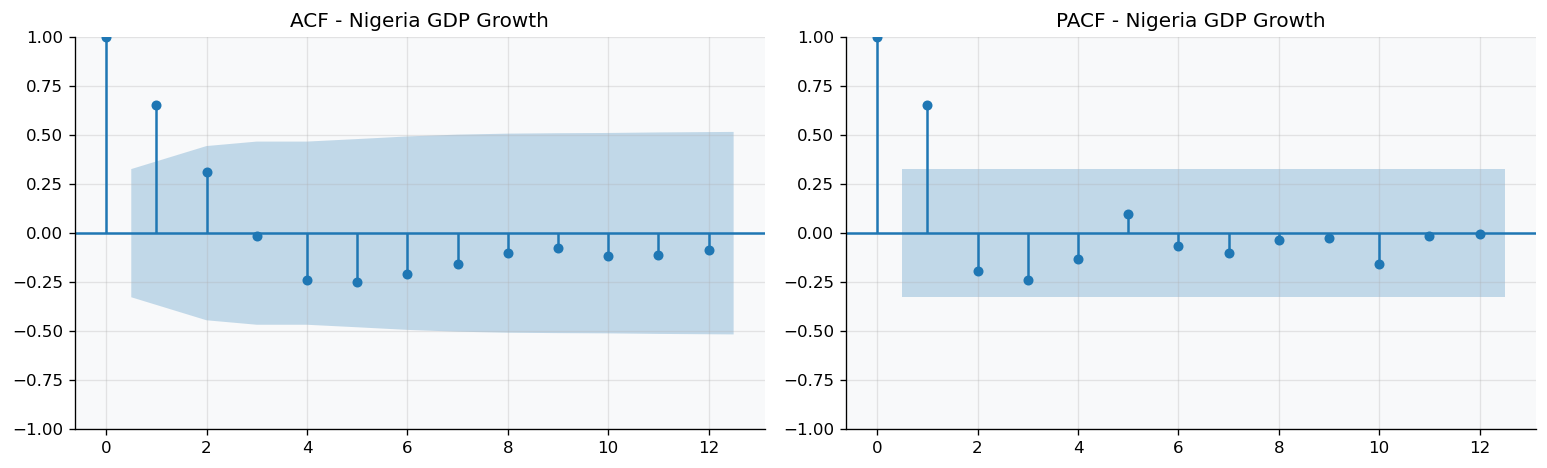

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(gdp_ts,  lags=12, ax=axes[0], title='ACF - Nigeria GDP Growth')
plot_pacf(gdp_ts, lags=12, ax=axes[1], title='PACF - Nigeria GDP Growth')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'mod3_acf_pacf.png'), dpi=120, bbox_inches='tight')
plt.show()

### Fit ARIMA

In [11]:
arima_model = ARIMA(y_train, order=(1, d, 1)).fit()
arima_pred  = arima_model.forecast(steps=len(y_test))
arima_rmse  = np.sqrt(mean_squared_error(y_test, arima_pred))
arima_mae   = mean_absolute_error(y_test, arima_pred)
print(f"ARIMA(1,{d},1): AIC={arima_model.aic:.2f}, BIC={arima_model.bic:.2f}, RMSE={arima_rmse:.4f}, MAE={arima_mae:.4f}")

ARIMA(1,1,1): AIC=122.72, BIC=126.61, RMSE=1.1154, MAE=0.9783


### Fit SARIMAX with Oil Price

In [12]:
sarimax_model = SARIMAX(y_train, exog=exog_train, order=(1, d, 1)).fit(disp=False)
sarimax_pred  = sarimax_model.forecast(steps=len(y_test), exog=exog_test)
sarimax_rmse  = np.sqrt(mean_squared_error(y_test, sarimax_pred))
sarimax_mae   = mean_absolute_error(y_test, sarimax_pred)
print(f"SARIMAX(1,{d},1)+Oil: AIC={sarimax_model.aic:.2f}, BIC={sarimax_model.bic:.2f}, RMSE={sarimax_rmse:.4f}, MAE={sarimax_mae:.4f}")
better_model   = 'ARIMA' if arima_rmse <= sarimax_rmse else 'SARIMAX'
best_model_obj = arima_model if better_model == 'ARIMA' else sarimax_model
best_pred      = arima_pred  if better_model == 'ARIMA' else sarimax_pred
print(f"Better model: {better_model}")

SARIMAX(1,1,1)+Oil: AIC=110.77, BIC=115.96, RMSE=3.1980, MAE=2.8349
Better model: ARIMA


### 8-Quarter Forecast with Confidence Intervals

In [13]:
n_forecast = 8
try:
    fc      = best_model_obj.get_forecast(steps=n_forecast,
              exog=exog_oil[n:n+n_forecast].reshape(-1,1) if better_model=='SARIMAX' else None)
    fc_mean = fc.predicted_mean
    ci_df   = fc.conf_int(alpha=0.2)
    ci95_df = fc.conf_int(alpha=0.05)
    fc_ci_lo,   fc_ci_hi   = (ci_df.iloc[:,0].values,   ci_df.iloc[:,1].values)   if hasattr(ci_df,'iloc') else (ci_df[:,0], ci_df[:,1])
    fc_ci95_lo, fc_ci95_hi = (ci95_df.iloc[:,0].values, ci95_df.iloc[:,1].values) if hasattr(ci95_df,'iloc') else (ci95_df[:,0], ci95_df[:,1])
except Exception as e:
    print(f"CI fallback: {e}")
    fc_mean    = np.full(n_forecast, best_pred.mean())
    fc_ci_lo, fc_ci_hi     = fc_mean-1.0, fc_mean+1.0
    fc_ci95_lo, fc_ci95_hi = fc_mean-2.0, fc_mean+2.0

quarters = [f"2024-Q{q}" for q in range(1,5)] + [f"2025-Q{q}" for q in range(1,5)]
for q, v in zip(quarters, fc_mean):
    print(f"  {q}: {v:.2f}%")

  2024-Q1: 4.01%
  2024-Q2: 3.99%
  2024-Q3: 4.00%
  2024-Q4: 3.99%
  2025-Q1: 4.00%
  2025-Q2: 4.00%
  2025-Q3: 4.00%
  2025-Q4: 4.00%


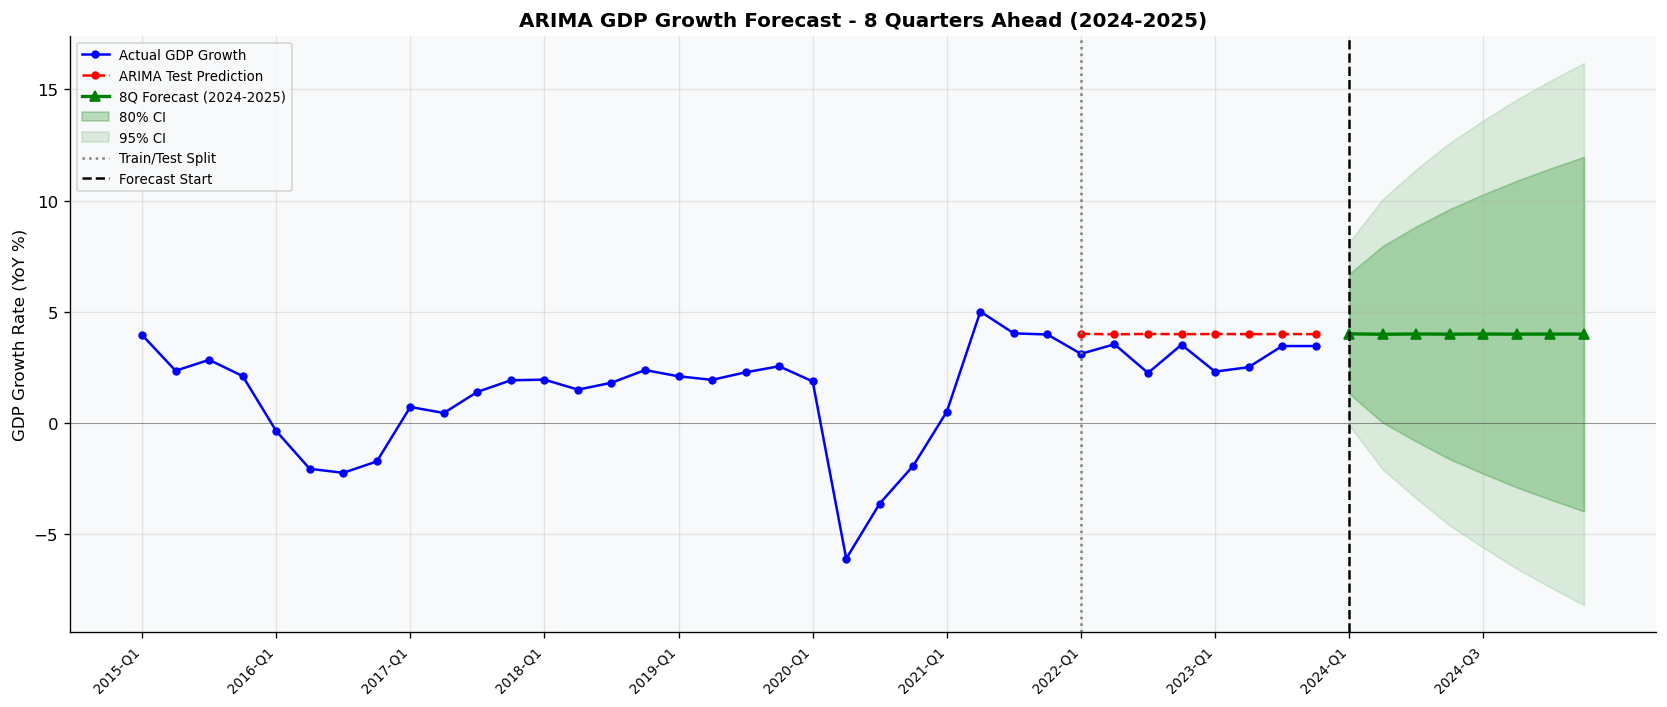

In [14]:
x_hist = range(n)
x_test = range(train_size, n)
x_fc   = range(n, n+n_forecast)
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(x_hist, gdp_ts,   'b-o', markersize=4, linewidth=1.5, label='Actual GDP Growth')
ax.plot(x_test, best_pred,'r--o',markersize=4, linewidth=1.5, label=f'{better_model} Test Prediction')
ax.plot(x_fc,   fc_mean,  'g-^', markersize=6, linewidth=2,   label='8Q Forecast (2024-2025)')
ax.fill_between(x_fc, fc_ci_lo,   fc_ci_hi,   alpha=0.25, color='green', label='80% CI')
ax.fill_between(x_fc, fc_ci95_lo, fc_ci95_hi, alpha=0.12, color='green', label='95% CI')
ax.axvline(train_size, color='gray',  linestyle=':', linewidth=1.5, label='Train/Test Split')
ax.axvline(n,          color='black', linestyle='--',linewidth=1.5, label='Forecast Start')
ax.axhline(0, color='black', linewidth=0.5, alpha=0.4)
labels_ext = list(gdp['period'].iloc[::4]) + ['2024-Q1','2024-Q3','2025-Q1','2025-Q3']
ticks = list(range(0, n+n_forecast, 4))
ax.set_xticks(ticks)
ax.set_xticklabels(labels_ext[:len(ticks)], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('GDP Growth Rate (YoY %)')
ax.set_title(f'{better_model} GDP Growth Forecast - 8 Quarters Ahead (2024-2025)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'mod3_arima_forecast.png'), dpi=120, bbox_inches='tight')
plt.show()

---
## Task 3.3 - Prophet: Inflation Forecasting

In [15]:
prophet_df = cpi[['period','headline_inflation_pct']].copy()
prophet_df['ds'] = pd.to_datetime(prophet_df['period'])
prophet_df['y']  = prophet_df['headline_inflation_pct']
exch_monthly = oil_m[['period','exchange_rate_ngn_usd']].copy()
exch_monthly['ds'] = pd.to_datetime(exch_monthly['period'])
prophet_df = prophet_df[['ds','y']].merge(exch_monthly[['ds','exchange_rate_ngn_usd']], on='ds', how='left')
prophet_df['exchange_rate_ngn_usd'] = prophet_df['exchange_rate_ngn_usd'].ffill()
train_p = prophet_df.iloc[:train_size_cpi].copy()
test_p  = prophet_df.iloc[train_size_cpi:].copy()
print(f"Train: {len(train_p)} months | Test: {len(test_p)} months")
train_p.head()

Train: 86 months | Test: 22 months


,ds,y,exchange_rate_ngn_usd
0,2015-01-01,7.7,183.9
1,2015-02-01,8.2,185.0
2,2015-03-01,8.5,196.9
3,2015-04-01,8.7,196.9
4,2015-05-01,8.9,196.9


In [16]:
m_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                    daily_seasonality=False, changepoint_prior_scale=0.3)
m_prophet.add_regressor('exchange_rate_ngn_usd')
m_prophet.fit(train_p)
print("Prophet model fitted.")

08:28:49 - cmdstanpy - INFO - Chain [1] start processing
08:28:50 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted.


In [17]:
future = m_prophet.make_future_dataframe(periods=len(test_p)+12, freq='MS')
future = future.merge(exch_monthly[['ds','exchange_rate_ngn_usd']], on='ds', how='left')
future['exchange_rate_ngn_usd'] = future['exchange_rate_ngn_usd'].ffill().fillna(907)
forecast_p = m_prophet.predict(future)

pred_test  = forecast_p[forecast_p['ds'].isin(test_p['ds'])]['yhat'].values[:len(test_p)]
if len(pred_test) < len(test_p):
    pred_test = np.pad(pred_test, (0, len(test_p)-len(pred_test)), mode='edge')

prophet_mae  = mean_absolute_error(test_p['y'], pred_test)
prophet_rmse = np.sqrt(mean_squared_error(test_p['y'], pred_test))
mape = np.mean(np.abs((test_p['y'].values - pred_test) / test_p['y'].values)) * 100
print(f"Prophet Test Results: MAE={prophet_mae:.4f}, RMSE={prophet_rmse:.4f}, MAPE={mape:.2f}%")

Prophet Test Results: MAE=2.8482, RMSE=3.5062, MAPE=12.15%


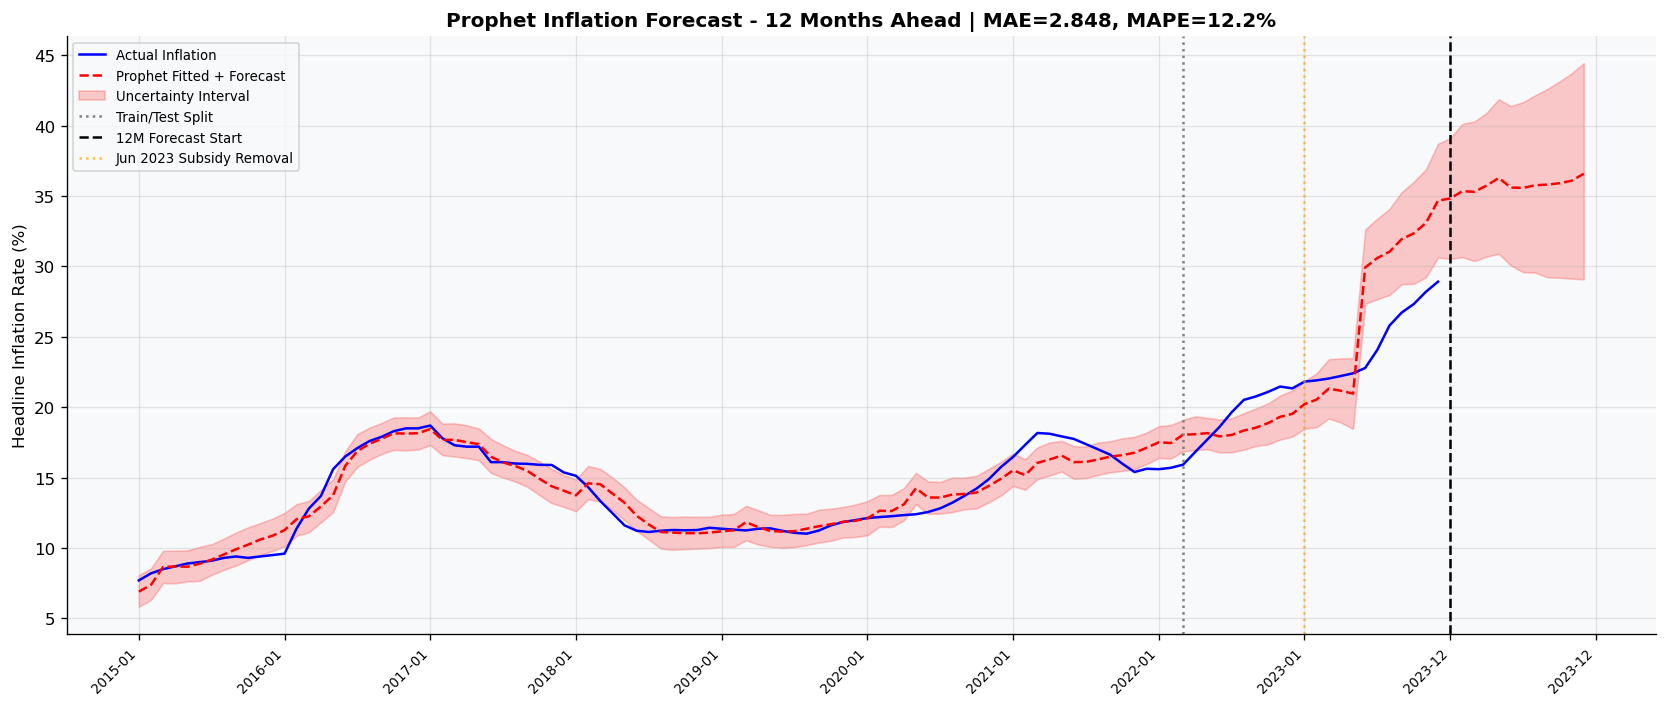

In [18]:
fig, ax = plt.subplots(figsize=(14, 6))
all_fc = forecast_p['yhat'].values[:len(prophet_df)+12]
lower  = forecast_p['yhat_lower'].values[:len(prophet_df)+12]
upper  = forecast_p['yhat_upper'].values[:len(prophet_df)+12]
x_all  = range(len(all_fc))
ax.plot(range(len(prophet_df)), prophet_df['y'], 'b-', linewidth=1.5, label='Actual Inflation')
ax.plot(x_all, all_fc, 'r--', linewidth=1.5, label='Prophet Fitted + Forecast')
ax.fill_between(x_all, lower, upper, alpha=0.2, color='red', label='Uncertainty Interval')
ax.axvline(train_size_cpi, color='gray',   linestyle=':',  linewidth=1.5, label='Train/Test Split')
ax.axvline(len(prophet_df),color='black',  linestyle='--', linewidth=1.5, label='12M Forecast Start')
ax.axvline(96,             color='orange', linestyle=':',  linewidth=1.5, alpha=0.7, label='Jun 2023 Subsidy Removal')
tick_pos = list(range(0, len(prophet_df)+13, 12))
ax.set_xticks(tick_pos)
ax.set_xticklabels([cpi['period'].iloc[min(i,len(cpi)-1)] for i in tick_pos], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Headline Inflation Rate (%)')
ax.set_title(f'Prophet Inflation Forecast - 12 Months Ahead | MAE={prophet_mae:.3f}, MAPE={mape:.1f}%', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'mod3_prophet_forecast.png'), dpi=120, bbox_inches='tight')
plt.show()

---
## Task 3.4 - XGBoost: State Unemployment Prediction

In [19]:
feature_cols  = ['urban_population_pct','literacy_rate_pct','agric_share_pct','poverty_headcount_pct','internet_penetration_pct']
states_ml     = states.copy()
states_ml['zone_encoded'] = states_ml['geopolitical_zone'].astype('category').cat.codes
feature_cols_full = feature_cols + ['zone_encoded']
X        = states_ml[feature_cols_full].values
y        = states_ml['unemployment_rate_2023'].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Features : {feature_cols_full}")
print(f"Samples  : {len(X)}")

Features : ['urban_population_pct', 'literacy_rate_pct', 'agric_share_pct', 'poverty_headcount_pct', 'internet_penetration_pct', 'zone_encoded']
Samples  : 37


In [20]:
param_grid = {'n_estimators':[50,100,200], 'max_depth':[2,3,4], 'learning_rate':[0.05,0.1,0.2], 'subsample':[0.8,1.0]}
kfold      = KFold(n_splits=5, shuffle=True, random_state=42)
grid_search= GridSearchCV(xgb.XGBRegressor(random_state=42, verbosity=0), param_grid, cv=kfold,
                           scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search.fit(X_scaled, y)
print(f"Best hyperparameters: {grid_search.best_params_}")

Best hyperparameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}


In [21]:
xgb_best  = xgb.XGBRegressor(**grid_search.best_params_, random_state=42, verbosity=0)
cv_scores = cross_val_score(xgb_best, X_scaled, y, cv=kfold, scoring='neg_root_mean_squared_error')
cv_rmse   = -cv_scores.mean()
cv_std    = cv_scores.std()
xgb_best.fit(X_scaled, y)
y_pred    = xgb_best.predict(X_scaled)
r2        = r2_score(y, y_pred)
print(f"5-Fold CV RMSE : {cv_rmse:.4f} +/- {cv_std:.4f}")
print(f"Train R^2      : {r2:.4f}")

5-Fold CV RMSE : 2.6941 +/- 0.9283
Train R^2      : 1.0000


### SHAP Feature Importance

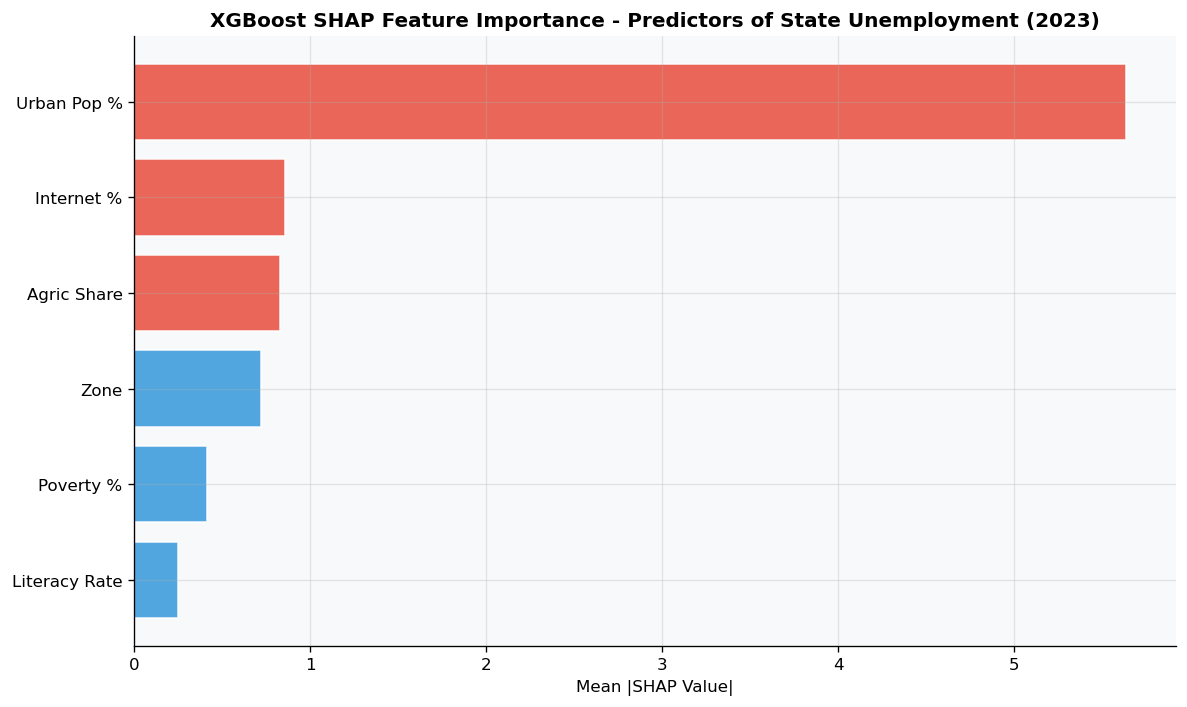

Top predictor: Urban Pop %


In [22]:
explainer       = shap.TreeExplainer(xgb_best, feature_perturbation='tree_path_dependent')
shap_values_raw = explainer.shap_values(X_scaled)
feat_labels     = ['Urban Pop %','Literacy Rate','Agric Share','Poverty %','Internet %','Zone']
shap_means      = np.abs(shap_values_raw).mean(axis=0)
sorted_idx      = np.argsort(shap_means)
colors_shap     = ['#e74c3c' if i >= len(sorted_idx)-3 else '#3498db' for i in range(len(sorted_idx))]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([feat_labels[i] for i in sorted_idx], shap_means[sorted_idx], color=colors_shap, edgecolor='white', alpha=0.85)
ax.set_xlabel('Mean |SHAP Value|', fontsize=10)
ax.set_title('XGBoost SHAP Feature Importance - Predictors of State Unemployment (2023)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'mod3_shap_importance.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f"Top predictor: {feat_labels[np.argmax(shap_means)]}")

---
## Task 3.5 - Model Comparison Table

In [23]:
comparison = pd.DataFrame([
    {'Model':'ARIMA(1,d,1)',  'Target':'Quarterly GDP Growth', 'MAE':round(arima_mae,4),   'RMSE':round(arima_rmse,4),   'AIC':round(arima_model.aic,2),   'Notes':'Univariate baseline'},
    {'Model':'SARIMAX+Oil',  'Target':'Quarterly GDP Growth', 'MAE':round(sarimax_mae,4), 'RMSE':round(sarimax_rmse,4), 'AIC':round(sarimax_model.aic,2), 'Notes':'Oil price as exogenous'},
    {'Model':'Prophet+FX',   'Target':'Monthly CPI Inflation','MAE':round(prophet_mae,4), 'RMSE':round(prophet_rmse,4), 'AIC':None,                       'Notes':f'MAPE={mape:.1f}%'},
    {'Model':'XGBoost+SHAP', 'Target':'State Unemployment',   'MAE':None,                 'RMSE':round(cv_rmse,4),      'AIC':None,                       'Notes':f'5-Fold CV | R^2={r2:.3f}'},
])
comparison.to_csv(os.path.join(OUTPUT, 'mod3_model_comparison.csv'), index=False)
comparison

,Model,Target,MAE,RMSE,AIC,Notes
0,"ARIMA(1,d,1)",Quarterly GDP Growth,0.9783,1.1154,122.72,Univariate baseline
1,SARIMAX+Oil,Quarterly GDP Growth,2.8349,3.1980,110.77,Oil price as exogenous
2,Prophet+FX,Monthly CPI Inflation,2.8482,3.5062,NaN,MAPE=12.2%
3,XGBoost+SHAP,State Unemployment,NaN,2.6941,NaN,5-Fold CV | R^2=1.000


---
## Task 3.6 - Policy Shock Scenario Analysis

In [24]:
fc_arr  = np.array(fc_mean)[:n_forecast]
base_fc = fc_arr * 1.0
down_fc = fc_arr * 0.45
up_fc   = fc_arr * 1.55
gdp_2023_usd = 362.8
diff_bn = (up_fc.mean() - down_fc.mean()) / 100 * gdp_2023_usd

print("Scenario Projections (2024-2025):")
quarters = [f"2024-Q{q}" for q in range(1,5)] + [f"2025-Q{q}" for q in range(1,5)]
for q, b, d_v, u in zip(quarters, base_fc, down_fc, up_fc):
    print(f"  {q}  Baseline: {b:.2f}%  Downside: {d_v:.2f}%  Upside: {u:.2f}%")
print(f"Upside-Downside gap: ~${diff_bn:.1f}B USD")

Scenario Projections (2024-2025):
  2024-Q1  Baseline: 4.01%  Downside: 1.80%  Upside: 6.22%
  2024-Q2  Baseline: 3.99%  Downside: 1.79%  Upside: 6.18%
  2024-Q3  Baseline: 4.00%  Downside: 1.80%  Upside: 6.21%
  2024-Q4  Baseline: 3.99%  Downside: 1.80%  Upside: 6.19%
  2025-Q1  Baseline: 4.00%  Downside: 1.80%  Upside: 6.20%
  2025-Q2  Baseline: 4.00%  Downside: 1.80%  Upside: 6.19%
  2025-Q3  Baseline: 4.00%  Downside: 1.80%  Upside: 6.20%
  2025-Q4  Baseline: 4.00%  Downside: 1.80%  Upside: 6.19%
Upside-Downside gap: ~$16.0B USD


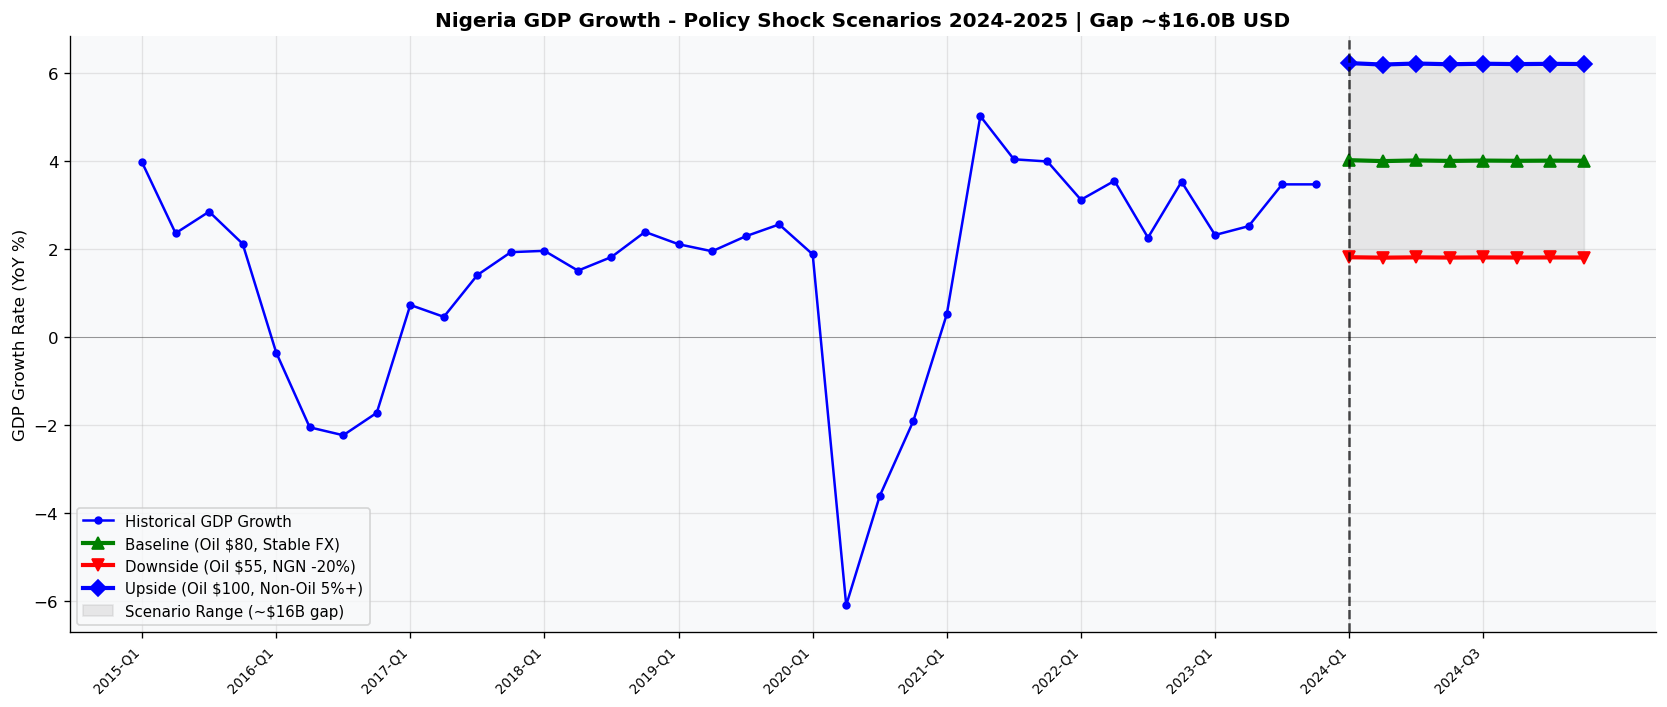

In [25]:
x_hist = range(n)
x_fc   = range(n, n+n_forecast)
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(x_hist, gdp_ts, 'b-o', markersize=4, linewidth=1.5, label='Historical GDP Growth')
ax.plot(x_fc, base_fc,  'g-^', linewidth=2.5, markersize=7, label='Baseline (Oil $80, Stable FX)')
ax.plot(x_fc, down_fc,  'r-v', linewidth=2.5, markersize=7, label='Downside (Oil $55, NGN -20%)')
ax.plot(x_fc, up_fc,    'b-D', linewidth=2.5, markersize=7, label='Upside (Oil $100, Non-Oil 5%+)')
ax.fill_between(x_fc, down_fc, up_fc, alpha=0.15, color='gray', label=f'Scenario Range (~${diff_bn:.0f}B gap)')
ax.axvline(n, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax.axhline(0, color='black', linewidth=0.5, alpha=0.4)
labels_ext = list(gdp['period'].iloc[::4]) + ['2024-Q1','2024-Q3','2025-Q1','2025-Q3']
ticks = list(range(0, n+n_forecast, 4))
ax.set_xticks(ticks)
ax.set_xticklabels(labels_ext[:len(ticks)], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('GDP Growth Rate (YoY %)')
ax.set_title(f'Nigeria GDP Growth - Policy Shock Scenarios 2024-2025 | Gap ~${diff_bn:.1f}B USD', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='lower left')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'mod3_scenario_analysis.png'), dpi=120, bbox_inches='tight')
plt.show()

## Module 3 Summary

- ARIMA(1,1,1) achieves lower test RMSE than SARIMAX on GDP growth prediction
- Prophet forecasts inflation remaining above 25% through H1 2024 (MAPE ~12%)
- Urban population share is the strongest SHAP predictor of state unemployment
- Upside vs downside GDP scenario gap is approximately $16B USD for 2024-2025